# AI Multi-Stop Planner — Hybrid (Pickup + Delivery)

**Pipeline:** Gmail → LLM Parse → Geocode → ORS Optimise → Before/After Matrix → Reply

**Graph:** Parallel matrix + optimisation nodes; before/after POV comparison; no retry overheads.

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from typing import TypedDict, Optional, List, Literal
import hashlib, logging, os, time
from datetime import datetime, timezone

load_dotenv()

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
log = logging.getLogger(__name__)

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY', '')

## Data Models

In [2]:
class StopContext(BaseModel):
    store_id: str = Field(description='Store identifier, e.g. STORE-101')
    store_name: str = Field(description='Store or company name')
    pickup_address: str = Field(description='Full pickup street address')
    delivery_address: str = Field(description='Full delivery street address')
    expected_pickup_time: Optional[str] = Field(None, description="e.g. '09:00'")
    expected_delivery_time: Optional[str] = Field(None, description="e.g. '13:00'")
    temperature_control: bool = Field(False, description='True if cold-chain required')
    collection_date: Optional[str] = Field(None, description="e.g. '2024-04-12'")


class ParsedEmailOutput(BaseModel):
    sender_name: str = Field(description='Name of the person who sent the email')
    sender_company: str = Field(description='Retailer company name')
    collection_date: Optional[str] = Field(None)
    stops: List[StopContext] = Field(description='All pickup stops in the email')

## Graph State

In [3]:
class LogisticsState(TypedDict):
    raw_email_content:      str
    sender_email:           str
    thread_id:              str
    collection_request_id:  str
    parsed_stops:           List[dict]
    geocoded_stops:         List[dict]
    sender_company:         str
    reply_html:             str
    email_log_saved:        bool
    error:                  Optional[str]
    rejected_stops:         List[dict]

    # Depot
    depot_latitude:         Optional[float]
    depot_longitude:        Optional[float]

    # Optimisation
    vehicle_count:          int
    opt_summary:            Optional[dict]  
    opt_routes:             List[dict]       
    ordered_stops:          List[dict]       

    
    unoptimized_matrix:     Optional[dict]   # legs[]
    optimized_matrix:       Optional[dict]   

In [4]:
from tools.sheets_tools import (
    check_duplicate, save_email_log, save_parsed_stops,
    save_geocoded, save_route, save_error, save_rejection,
)
from tools.ors_tools import (
    geocode_address, optimize_route, elevation_point, distance_matrix, calculate_route_distance,
)
from tools.gmail_tools import send_gmail_reply

DEPOT_ADDRESS    = os.getenv('DEPOT_ADDRESS', '')
# Manual override: if set, skip geocoding the depot entirely
DEPOT_LAT        = float(os.getenv('DEPOT_LAT', '0')) or None
DEPOT_LON        = float(os.getenv('DEPOT_LON', '0')) or None
MAX_VEHICLES     = int(os.getenv('MAX_VEHICLES', '2'))
VEHICLE_CAPACITY = int(os.getenv('VEHICLE_CAPACITY', '100'))
log.info('Fleet config: max_vehicles=%d, vehicle_capacity=%d', MAX_VEHICLES, VEHICLE_CAPACITY)
if DEPOT_LAT and DEPOT_LON:
    log.info('Depot override: (%.5f, %.5f)', DEPOT_LAT, DEPOT_LON)

2026-04-24 23:17:04,222 [INFO] Fleet config: max_vehicles=2, vehicle_capacity=100
2026-04-24 23:17:04,222 [INFO] Depot override: (18.98940, 73.11750)


## Graph Nodes

In [5]:
def gmail_trigger(state: LogisticsState) -> dict:
    ts  = datetime.now(timezone.utc)
    # Hash is based on thread_id so same email always produces same req_id
    h6  = hashlib.md5(state['thread_id'].encode()).hexdigest()[:6]
    req_id = f"REQ-{ts.strftime('%Y%m%d')}-{h6}"

    if check_duplicate(req_id):
        log.warning('Duplicate request: %s', req_id)
        return {'collection_request_id': req_id, 'error': 'DUPLICATE_REQUEST'}

    log.info('New request: %s (thread: %s)', req_id, state['thread_id'])
    return {'collection_request_id': req_id, 'error': None}


def route_after_trigger(state: LogisticsState) -> Literal['parser_agent', 'error_handler']:
    return 'error_handler' if state.get('error') else 'parser_agent'

In [6]:
PARSER_SYSTEM_PROMPT = """\
You are a logistics data extraction assistant.
Parse the email and extract all pickup/collection stops.

For each stop extract:
- store_id: store identifier (e.g. "STORE-101")
- store_name: name of the store or company
- pickup_address: full street pickup address
- delivery_address: full delivery street address
- expected_pickup_time: optional, e.g. "09:00"
- expected_delivery_time: optional, e.g. "13:00"
- temperature_control: true ONLY if cold-chain/refrigeration is explicitly mentioned
- collection_date: optional, e.g. "2024-04-12"

Rules:
- Use null for optional fields not mentioned.
- Do NOT invent information, only extract what is explicitly stated.
- Output must conform exactly to the schema.
"""

parser_llm = ChatOpenAI(model='gpt-4o').with_structured_output(ParsedEmailOutput)


def parser_agent(state: LogisticsState) -> dict:
    try:
        result = parser_llm.invoke([
            SystemMessage(content=PARSER_SYSTEM_PROMPT),
            HumanMessage(content=f"Parse this collection request email:\n\n{state['raw_email_content']}"),
        ])
        if not result.stops:
            raise ValueError('LLM returned zero stops')
    except Exception as e:
        log.error('Parser failed: %s', e)
        return {'error': 'PARSE_FAILED', 'parsed_stops': []}

    stops = [s.model_dump() for s in result.stops]
    log.info('Parsed %d stops (sender: %s)', len(stops), result.sender_company)
    return {'parsed_stops': stops, 'sender_company': result.sender_company, 'error': None}


In [7]:
def route_after_parse(state: LogisticsState) -> Literal['save_email_logs_to_sheet', 'error_handler']:
    return 'error_handler' if state.get('error') else 'save_email_logs_to_sheet'

In [8]:
def save_email_logs_to_sheet(state: LogisticsState) -> dict:
    req_id = state['collection_request_id']
    save_email_log.invoke({
        'collection_request_id': req_id,
        'sender_email': state['sender_email'],
        'sender_company': state.get('sender_company', ''),
        'raw_body': state['raw_email_content'],
    })
    save_parsed_stops.invoke({'collection_request_id': req_id, 'stops': state['parsed_stops']})
    log.info('Logs saved: %d stops for %s', len(state['parsed_stops']), req_id)
    return {'email_log_saved': True}

In [ ]:
def geocode_pickup_delivery_address(state: LogisticsState) -> dict:
    """
    Geocode all pickup + delivery addresses and the DEPOT.
    Depot lat/lon is stored in state for downstream nodes.
    """
    stops  = state['parsed_stops']
    req_id = state['collection_request_id']
    geocoded_stops: list = []
    geocode_rows:   list = []

    for i, stop in enumerate(stops):
        seq      = i + 1
        stop_geo = {**stop, 'original_sequence': seq, 'stop_index': i}

        for addr_type in ('pickup', 'delivery'):
            raw_addr = stop[f'{addr_type}_address']
            try:
                geo = geocode_address.invoke({'address': raw_addr})
                try:
                    elev = elevation_point.invoke({'latitude': geo['latitude'], 'longitude': geo['longitude']})
                    elevation = elev.get('elevation')
                except Exception as ee:
                    log.warning('Elevation failed for %s stop %d: %s', addr_type, seq, ee)
                    elevation = None

                stop_geo.update({
                    f'{addr_type}_latitude':    geo['latitude'],
                    f'{addr_type}_longitude':   geo['longitude'],
                    f'{addr_type}_confidence':  geo['confidence'],
                    f'{addr_type}_elevation_m': elevation,
                })

                geocode_rows.append({
                    'stop_number':      seq,
                    'store_name':       stop['store_name'],
                    'address_type':     addr_type,
                    'raw_address':      raw_addr,
                    'latitude':         geo['latitude'],
                    'longitude':        geo['longitude'],
                    'confidence':       geo['confidence'],
                    'elevation_m':      elevation,
                })
                log.info('Geocoded %s stop %d: (%.5f, %.5f) conf=%.2f',
                         addr_type, seq, geo['latitude'], geo['longitude'], geo['confidence'])

            except Exception as e:
                log.warning('GEOCODE_FAILED %s stop %d "%s": %s', addr_type, seq, raw_addr, e)
                stop_geo[f'{addr_type}_latitude']  = None
                stop_geo[f'{addr_type}_longitude'] = None

        geocoded_stops.append(stop_geo)

    if geocode_rows:
        save_geocoded.invoke({'collection_request_id': req_id, 'geo_data': geocode_rows})
        log.info('Geocoded sheet saved: %d entries for %s', len(geocode_rows), req_id)

    valid = [s for s in geocoded_stops if s.get('pickup_latitude') is not None]
    if not valid:
        return {'geocoded_stops': [], 'error': 'GEOCODE_FAILED'}

    depot_lat = DEPOT_LAT
    depot_lon = DEPOT_LON

    if depot_lat and depot_lon:
        log.info('Using manual depot override: (%.5f, %.5f)', depot_lat, depot_lon)
    elif DEPOT_ADDRESS:
        try:
            depot_geo = geocode_address.invoke({'address': DEPOT_ADDRESS})
            # Guard: reject depot geocoding with very low confidence
            if depot_geo['confidence'] < 0.5:
                log.error('Depot geocoded with LOW confidence %.2f → (%.5f, %.5f) for "%s". '
                          'Set DEPOT_LAT/DEPOT_LON env vars for reliable coordinates.',
                          depot_geo['confidence'], depot_geo['latitude'], depot_geo['longitude'],
                          DEPOT_ADDRESS)
                return {'geocoded_stops': geocoded_stops, 'error': 'DEPOT_GEOCODE_LOW_CONFIDENCE'}
            depot_lat = depot_geo['latitude']
            depot_lon = depot_geo['longitude']
            log.info('Depot geocoded: (%.5f, %.5f) conf=%.2f', depot_lat, depot_lon, depot_geo['confidence'])
        except Exception as e:
            log.error('Depot geocode failed: %s', e)
            return {'geocoded_stops': geocoded_stops, 'error': 'DEPOT_GEOCODE_FAILED'}
    else:
        log.error('DEPOT_ADDRESS env not set and no DEPOT_LAT/DEPOT_LON override')
        return {'geocoded_stops': geocoded_stops, 'error': 'DEPOT_GEOCODE_FAILED'}

    return {
        'geocoded_stops':  geocoded_stops,
        'depot_latitude':  depot_lat,
        'depot_longitude': depot_lon,
        'error':           None,
    }


In [10]:
def route_after_geocode(
    state: LogisticsState,
) -> Literal['matrix_unoptimized', 'error_handler']:
    """
    Router after geocoding step.
    Flows sequentially: geocode → matrix_unoptimized → route_optimization → ...
    This avoids the fan-out/fan-in pattern that caused duplicate replies.
    """
    return 'error_handler' if state.get('error') else 'matrix_unoptimized'


In [11]:
def matrix_unoptimized(state: LogisticsState) -> dict:

    if state.get('error'):
        return {'unoptimized_matrix': None}

    depot_lat      = state.get('depot_latitude')
    depot_lon      = state.get('depot_longitude')
    geocoded_stops = state.get('geocoded_stops', [])

    if not geocoded_stops or depot_lat is None:
        return {'unoptimized_matrix': None}

    locs = [{'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon}]

    for s in sorted(geocoded_stops, key=lambda x: x.get('original_sequence', 0)):
        for addr_type in ('pickup', 'delivery'):
            lat = s.get(f'{addr_type}_latitude')
            lon = s.get(f'{addr_type}_longitude')
            if lat is None or lon is None:
                log.warning('Skipping %s %s — missing coords', s.get('store_name'), addr_type)
                continue
            locs.append({
                'store_name': f"{s['store_name']} ({addr_type.title()})",
                'latitude':   lat,
                'longitude':  lon,
            })

    locs.append({'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon})

    if len(locs) < 3:
        return {'unoptimized_matrix': None}

    try:
        result = distance_matrix.invoke({'locations': locs, 'profile': 'driving-car'})
        result['stop_count'] = len(locs) - 2  # exclude depot start + end
        log.info('Unoptimised matrix (email order): %.1f km | %.1f min',
                 result['total_distance_km'], result['total_duration_min'])
        return {'unoptimized_matrix': result}
    except Exception as e:
        log.warning('Unoptimised matrix failed: %s', e)
        return {'unoptimized_matrix': None}

In [12]:
def route_optimization(state: LogisticsState) -> dict:
    """
    Call ORS /optimization (VROOM).
    optimize_route() returns everything already parsed:
      summary, routes, ordered_stops, unassigned_stops.
    This node just invokes it and maps results into state.
    """
    if state.get("error"):
        return {
            "opt_summary":    None,
            "opt_routes":     [],
            "ordered_stops":  [],
            "rejected_stops": [],
            "vehicle_count":  0,
        }

    req_id    = state["collection_request_id"]
    depot_lat = state["depot_latitude"]
    depot_lon = state["depot_longitude"]
    valid     = [s for s in state["geocoded_stops"] if s.get("pickup_latitude") is not None]

    try:
        result = optimize_route.invoke({
            "stops":            valid,
            "depot_lon":        depot_lon,
            "depot_lat":        depot_lat,
            "max_vehicles":     MAX_VEHICLES,
            "vehicle_capacity": VEHICLE_CAPACITY,
            "use_pd_pairs":     True,
        })
    except Exception as e:
        log.error("ORS optimisation failed: %s", e)
        return {
            "opt_summary":    None,
            "opt_routes":     [],
            "ordered_stops":  [],
            "rejected_stops": [],
            "vehicle_count":  0,
            "error":          "OPTIMIZATION_FAILED",
        }

    rejected_stops  = result["unassigned_stops"]
    ordered_stops   = result["ordered_stops"]
    routes          = result["routes"]
    vehicle_count   = len(routes)

    save_route.invoke({"collection_request_id": req_id, "route": {
        "summary":       result["summary"],
        "vehicle_count": vehicle_count,
        "ordered_stops": ordered_stops,
    }})
    log.info("Route optimised: %d stops, %d vehicle(s), %d unassigned",
             len(ordered_stops), vehicle_count, len(rejected_stops))

    return {
        "opt_summary":    result["summary"],
        "opt_routes":     routes,
        "ordered_stops":  ordered_stops,
        "rejected_stops": rejected_stops,
        "vehicle_count":  vehicle_count,
        "error":          None,
    }

In [13]:
def matrix_optimized(state: LogisticsState) -> dict:
    """
    Location sequence: DEPOT → optimised_stop1 → optimised_stop2 → ... → DEPOT

    Stores result in state['optimized_matrix']:
      { legs[], total_distance_km, total_duration_min }
    """
    if state.get('error') or not state.get('ordered_stops'):
        return {'optimized_matrix': None}

    depot_lat     = state.get('depot_latitude')
    depot_lon     = state.get('depot_longitude')
    ordered_stops = state['ordered_stops']

    if not ordered_stops or depot_lat is None:
        return {'optimized_matrix': None}

    locs = [{'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon}]
    for s in ordered_stops:
        locs.append({
            'store_name': f"{s['store_name']} ({s.get('stop_type', 'stop').title()})",
            'latitude':   s['latitude'],
            'longitude':  s['longitude'],
        })
    locs.append({'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon})

    try:
        result = distance_matrix.invoke({'locations': locs, 'profile': 'driving-car'})
        result['stop_count'] = len(locs) - 2  # exclude depot start + end
        log.info('Optimised matrix: %.1f km | %.1f min',
                 result['total_distance_km'], result['total_duration_min'])
        return {'optimized_matrix': result}
    except Exception as e:
        log.warning('Optimised matrix failed: %s', e)
        return {'optimized_matrix': None}

In [14]:
def route_after_optimized_matrix(state: LogisticsState) -> Literal['ai_agent_reply', 'rejection_agent_reply', 'error_handler']:
    """Route to the correct reply node after all data is ready."""
    if state.get('error'):
        return 'error_handler'
    if state.get('rejected_stops') or not state.get('ordered_stops'):
        return 'rejection_agent_reply'
    return 'ai_agent_reply'


In [ ]:
def _fmt_seconds(secs: int) -> str:
    """Convert seconds to 'Xhr Ymin' string."""
    h, rem = divmod(int(secs), 3600)
    m = rem // 60
    return f'{h}h {m:02d}min' if h else f'{m}min'

def _fmt_arrival(secs: int) -> str:
    """Convert seconds-since-midnight to HH:MM."""
    h, rem = divmod(int(secs), 3600)
    return f'{h:02d}:{rem // 60:02d}'

_REJECTION_REASONS = {
    'TIME_WINDOW_CONFLICT':  'Could not be served within the requested time window',
    'CAPACITY_EXCEEDED':     'Vehicle capacity limit reached',
    'PRECEDENCE_VIOLATION':  'Pickup-delivery ordering constraint violated',
    'unknown':               'Could not be assigned to any available vehicle',
}

_TABLE_STYLE = (
    'border-collapse:collapse;font-family:Arial,sans-serif;'
    'font-size:13px;width:100%;margin-bottom:8px'
)
_TD = 'padding:7px 10px;border:1px solid #d0d0d0;vertical-align:top'
_TD_ALT = 'padding:7px 10px;border:1px solid #d0d0d0;vertical-align:top;background:#f9f9f9'


def _build_stop_table(ordered_stops: list) -> str:
    """Confirmed stop sequence table, grouped by vehicle."""
    current_vehicle = None
    rows = ''
    for s in ordered_stops:
        vid = s.get('vehicle_id', 1)
        if vid != current_vehicle:
            current_vehicle = vid
            rows += (
                f'<tr style="background:#2c3e50;color:white">'
                f'<td colspan="7" style="{_TD};font-weight:bold;letter-spacing:0.5px">'
                f'&#128665; Vehicle {vid}</td></tr>'
            )

        badge = (
            '<span style="color:#e67e22;font-weight:bold">&#8679; Pickup</span>'
            if s.get('stop_type') == 'pickup'
            else '<span style="color:#2980b9;font-weight:bold">&#8681; Delivery</span>'
        )
        cold = ' &#10052;' if s.get('temperature_control') else ''
        addr = s.get('address', s.get('pickup_address', ''))
        eta  = _fmt_arrival(s.get('arrival_time_seconds', 0))
        svc  = _fmt_seconds(s.get('service_duration_seconds', 300))
        wait = _fmt_seconds(s.get('waiting_time_seconds', 0))
        td   = _TD_ALT if vid % 2 == 0 else _TD
        rows += (
            f'<tr>'
            f'<td style="{td};text-align:center;font-weight:bold">{s.get("optimized_sequence", "")}</td>'
            f'<td style="{td}">{s["store_name"]}{cold}</td>'
            f'<td style="{td}">{badge}</td>'
            f'<td style="{td}">{addr}</td>'
            f'<td style="{td};text-align:center;font-weight:bold">{eta}</td>'
            f'<td style="{td};text-align:center;color:#888">{wait}</td>'
            f'<td style="{td};text-align:center">{svc}</td>'
            f'</tr>'
        )
    th = 'padding:8px 10px;border:1px solid #555;font-weight:bold;text-align:left'
    return (
        f'<table style="{_TABLE_STYLE}">'
        f'<thead><tr style="background:#34495e;color:white">'
        f'<th style="{th};text-align:center">#</th>'
        f'<th style="{th}">Store</th>'
        f'<th style="{th}">Type</th>'
        f'<th style="{th}">Address</th>'
        f'<th style="{th};text-align:center">ETA</th>'
        f'<th style="{th};text-align:center">Wait</th>'
        f'<th style="{th};text-align:center">Service</th>'
        f'</tr></thead><tbody>' + rows + '</tbody></table>'
    )


def _compute_vehicle_distance(vehicle_route: dict, ordered_stops: list, depot_lat: float, depot_lon: float) -> float:
    """
    Calculate actual road distance (in km) for a vehicle's route using accurate ORS routing.

    VROOM optimization returns duration but NOT distance. We compute distance
    by building the location sequence (DEPOT -> stops -> DEPOT) and using the 
    calculate_route_distance function which calls ORS /routes endpoint.

    Args:
        vehicle_route: VROOM route dict with steps
        ordered_stops: All ordered stops from optimization
        depot_lat, depot_lon: Depot coordinates

    Returns:
        Distance in kilometers
    """
    # Extract stops for this vehicle in order
    vehicle_stop_ids = set()
    for step in vehicle_route.get('steps', []):
        if step.get('type') in ('pickup', 'delivery', 'job'):
            vehicle_stop_ids.add(step.get('id'))

    if not vehicle_stop_ids:
        return 0.0

    # Build location sequence: DEPOT -> stops -> DEPOT
    locs = [{'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon}]


    for stop in ordered_stops:
        job_id = stop.get('job_id')
        if job_id in vehicle_stop_ids:
            locs.append({
                'store_name': f"{stop['store_name']} ({stop.get('stop_type', 'stop').title()})",
                'latitude': stop['latitude'],
                'longitude': stop['longitude'],
            })

    locs.append({'store_name': 'DEPOT', 'latitude': depot_lat, 'longitude': depot_lon})

    if len(locs) < 3:
        return 0.0

    try:
        # Use calculate_route_distance for accurate road geometry calculation
        result = calculate_route_distance.invoke({'locations': locs, 'profile': 'driving-hgv'})
        return result.get('total_distance_km', 0.0)
    except Exception as e:
        log.warning('Distance calculation for vehicle %d failed: %s', vehicle_route.get('vehicle', 0), e)

        try:
            result = distance_matrix.invoke({'locations': locs, 'profile': 'driving-hgv'})
            return result.get('total_distance_km', 0.0)
        except Exception:
            duration_min = vehicle_route.get('duration', 0) / 60
            return round(duration_min * 50, 2)


def _build_vehicle_table(opt_routes: list, ordered_stops: list, depot_lat: float, depot_lon: float) -> str:
    """Per-vehicle breakdown — drive time, service time, distance."""
    rows = ''
    for i, r in enumerate(opt_routes):
        stop_count = sum(
            1 for step in r.get('steps', [])
            if step.get('type') in ('job', 'pickup', 'delivery')
        )
        drive_secs = max(0, r.get('duration', 0) - r.get('service', 0) - r.get('waiting_time', 0))

        distance_km = _compute_vehicle_distance(r, ordered_stops, depot_lat, depot_lon)
        dist_str = f'{distance_km} km'

        td = _TD_ALT if i % 2 == 0 else _TD
        rows += (
            f'<tr>'
            f'<td style="{td};font-weight:bold">&#128665; Vehicle {r["vehicle"]}</td>'
            f'<td style="{td};text-align:center">{stop_count}</td>'
            f'<td style="{td};text-align:center">{dist_str}</td>'
            f'<td style="{td};text-align:center">{_fmt_seconds(drive_secs)}</td>'
            f'<td style="{td};text-align:center">{_fmt_seconds(r.get("service", 0))}</td>'
            f'<td style="{td};text-align:center;color:#888">{_fmt_seconds(r.get("waiting_time", 0))}</td>'
            f'</tr>'
        )
    th = 'padding:8px 10px;border:1px solid #555;font-weight:bold;text-align:left'
    return (
        f'<table style="{_TABLE_STYLE}">'
        f'<thead><tr style="background:#34495e;color:white">'
        f'<th style="{th}">Vehicle</th>'
        f'<th style="{th};text-align:center">Stops</th>'
        f'<th style="{th};text-align:center">Distance</th>'
        f'<th style="{th};text-align:center">Drive Time</th>'
        f'<th style="{th};text-align:center">Service Time</th>'
        f'<th style="{th};text-align:center">Wait Time</th>'
        f'</tr></thead><tbody>' + rows + '</tbody></table>'
    )


def _build_pov_comparison(unopt: Optional[dict], opt: Optional[dict]) -> str:
    """Before/after comparison with % improvement and stop-count note."""
    if not unopt or not opt:
        return ''

    saved_km  = round(unopt['total_distance_km']  - opt['total_distance_km'],  1)
    saved_min = round(unopt['total_duration_min'] - opt['total_duration_min'], 1)

    pct_km  = round(saved_km  / unopt['total_distance_km']  * 100, 1) if unopt['total_distance_km']  else 0
    pct_min = round(saved_min / unopt['total_duration_min'] * 100, 1) if unopt['total_duration_min'] else 0

    def _sav_color(v: float) -> str:
        return '#27ae60' if v > 0 else '#e74c3c'

    th = 'padding:8px 10px;border:1px solid #555;font-weight:bold;text-align:left'
    td_l = f'{_TD};font-weight:bold'
    td_v = f'{_TD};text-align:center'

    rows = (
        f'<tr>'
        f'<td style="{td_l}">Distance</td>'
        f'<td style="{td_v}">{unopt["total_distance_km"]} km</td>'
        f'<td style="{td_v}">{opt["total_distance_km"]} km</td>'
        f'<td style="{td_v};color:{_sav_color(saved_km)};font-weight:bold">{saved_km:+.1f} km</td>'
        f'<td style="{td_v};color:{_sav_color(pct_km)};font-weight:bold">{pct_km:+.1f}%</td>'
        f'</tr>'
        f'<tr style="background:#f9f9f9">'
        f'<td style="{td_l}">Drive Time</td>'
        f'<td style="{td_v}">{unopt["total_duration_min"]} min</td>'
        f'<td style="{td_v}">{opt["total_duration_min"]} min</td>'
        f'<td style="{td_v};color:{_sav_color(saved_min)};font-weight:bold">{saved_min:+.1f} min</td>'
        f'<td style="{td_v};color:{_sav_color(pct_min)};font-weight:bold">{pct_min:+.1f}%</td>'
        f'</tr>'
    )

    unopt_sc = unopt.get('stop_count')
    opt_sc   = opt.get('stop_count')
    note = ''
    if unopt_sc and opt_sc and unopt_sc != opt_sc:
        rejected_n = unopt_sc - opt_sc
        note = (
            f'<tr><td colspan="5" style="{_TD};background:#fff3cd;color:#856404;font-size:12px">'
            f'&#9888; Note: Original routes covers {unopt_sc} location(s); '
            f'optimised routes covers {opt_sc} ({rejected_n} rejected). '
            f'Savings reflect served stops only.</td></tr>'
        )

    return (
        f'<table style="{_TABLE_STYLE}">'
        f'<thead><tr style="background:#16a085;color:white">'
        f'<th style="{th}">Metric</th>'
        f'<th style="{th};text-align:center">Original Order</th>'
        f'<th style="{th};text-align:center">Optimised (VROOM)</th>'
        f'<th style="{th};text-align:center">Saving</th>'
        f'<th style="{th};text-align:center">% Improvement</th>'
        f'</tr></thead><tbody>' + rows + note + '</tbody></table>'
    )


def _build_rejection_table(rejected: list) -> str:
    rows = ''
    for i, r in enumerate(rejected):
        reason_code = r.get('reason', 'unknown')
        reason_text = _REJECTION_REASONS.get(reason_code, _REJECTION_REASONS['unknown'])
        td = _TD_ALT if i % 2 == 0 else _TD
        rows += (
            f'<tr>'
            f'<td style="{td};font-weight:bold">{r["store_name"]}</td>'
            f'<td style="{td}">{r["stop_type"].title()}</td>'
            f'<td style="{td}">{r["address"]}</td>'
            f'<td style="{td};color:#c0392b">{reason_text}</td>'
            f'</tr>'
        )
    th = 'padding:8px 10px;border:1px solid #555;font-weight:bold;text-align:left'
    return (
        f'<table style="{_TABLE_STYLE}">'
        f'<thead><tr style="background:#c0392b;color:white">'
        f'<th style="{th}">Store</th>'
        f'<th style="{th}">Type</th>'
        f'<th style="{th}">Address</th>'
        f'<th style="{th}">Reason</th>'
        f'</tr></thead><tbody>' + rows + '</tbody></table>'
    )

In [16]:
import re as _re

REPLY_SYSTEM_PROMPT = """\
You are a professional logistics coordinator.
Write ONLY a brief 2-3 sentence opening paragraph for a route confirmation email.
Output ONLY the raw text — no HTML tags, no markdown, no code blocks, no headings.
Just plain sentences.
"""

REJECTION_SYSTEM_PROMPT = """\
You are a professional logistics coordinator sending a partial rejection email.
Write ONLY a brief 2-3 sentence opening paragraph acknowledging the request,
stating which stops were confirmed and which could not be served.
Output ONLY the raw text — no HTML tags, no markdown, no code blocks, no headings.
Just plain sentences.
"""

reply_llm = ChatOpenAI(model='gpt-4.1-mini')

_SECTION_H3 = 'font-family:Arial,sans-serif;color:#2c3e50;margin:18px 0 6px 0;font-size:15px'
_CLOSING_HTML = (
    '<p style="font-family:Arial,sans-serif;font-size:13px;color:#555;margin-top:16px">'
    'Please do not hesitate to contact us for any queries or amendments.<br>'
    '<strong>Logistics Operations Team</strong></p>'
)


def _sanitize_intro(raw: str) -> str:
    """
    Ensure the LLM intro is a clean <p> tag, stripping any markdown
    code fences, stray HTML wrappers, or extra whitespace.
    """
    text = raw.strip()
    # Strip markdown code fences: ```html ... ``` or ``` ... ```
    text = _re.sub(r'^```(?:html)?\s*', '', text)
    text = _re.sub(r'\s*```$', '', text)
    # Strip full HTML doc wrappers if the LLM added them
    text = _re.sub(r'</?(?:html|head|body|div)(?:\s[^>]*)?>',  '', text, flags=_re.IGNORECASE)
    text = text.strip()
    # If already wrapped in <p>, keep it; otherwise wrap it
    if not text.lower().startswith('<p'):
        text = (
            f'<p style="font-family:Arial,sans-serif;font-size:14px;'
            f'color:#333;line-height:1.5;margin:0 0 12px 0">{text}</p>'
        )
    return text


def _assemble_email(intro_html: str, sections: list, closing_html: str) -> str:
    """Join intro + table sections + closing into a complete HTML body."""
    parts = [intro_html]
    for heading, table_html in sections:
        if table_html:
            parts.append(f'<h3 style="{_SECTION_H3}">{heading}</h3>{table_html}')
    parts.append(closing_html)
    return ''.join(parts)


def ai_agent_reply(state: LogisticsState) -> dict:
    req_id         = state['collection_request_id']
    ordered_stops  = state.get('ordered_stops', [])
    opt_routes     = state.get('opt_routes', [])
    vc             = state.get('vehicle_count', 0)
    sender_company = state.get('sender_company', 'Valued Partner')
    depot_lat      = state.get('depot_latitude', 0.0)
    depot_lon      = state.get('depot_longitude', 0.0)
    s              = state.get('opt_summary') or {}

    user_prompt = (
        f"Company: {sender_company}\n"
        f"Request ID: {req_id}\n"
        f"Vehicles dispatched: {vc}\n"
        f"Total drive duration: {_fmt_seconds(s.get('duration', 0))}\n"
        f"Total stops confirmed: {len(ordered_stops) // 2}\n"
        "Write a brief opening paragraph confirming the route is optimised and ready."
    )
    raw_intro = reply_llm.invoke([
        SystemMessage(content=REPLY_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt),
    ]).content
    intro = _sanitize_intro(raw_intro)

    sections = [
        ('Before / After Comparison',
         _build_pov_comparison(state.get('unoptimized_matrix'), state.get('optimized_matrix'))),
        ('Per-Vehicle Breakdown',
         _build_vehicle_table(opt_routes, ordered_stops, depot_lat, depot_lon) if opt_routes else ''),
        ('Confirmed Stop Sequence',
         _build_stop_table(ordered_stops) if ordered_stops else ''),
    ]

    html = _assemble_email(intro, sections, _CLOSING_HTML)
    log.info('Reply HTML assembled: %d chars, %d stops', len(html), len(ordered_stops))
    return {'reply_html': html}


def rejection_agent_reply(state: LogisticsState) -> dict:
    req_id         = state['collection_request_id']
    ordered_stops  = state.get('ordered_stops', [])
    opt_routes     = state.get('opt_routes', [])
    rejected       = state.get('rejected_stops', [])
    sender_company = state.get('sender_company', 'Valued Partner')
    depot_lat      = state.get('depot_latitude', 0.0)
    depot_lon      = state.get('depot_longitude', 0.0)
    s              = state.get('opt_summary') or {}

    user_prompt = (
        f"Company: {sender_company}\n"
        f"Request ID: {req_id}\n"
        f"Confirmed stops: {len(ordered_stops) // 2}\n"
        f"Rejected stops: {len(rejected)}\n"
        "Write a brief opening paragraph acknowledging which stops were confirmed "
        "and which could not be served."
    )
    raw_intro = reply_llm.invoke([
        SystemMessage(content=REJECTION_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt),
    ]).content
    intro = _sanitize_intro(raw_intro)

    sections = []
    if ordered_stops:
        sections += [
            ('Before / After Comparison',
             _build_pov_comparison(state.get('unoptimized_matrix'), state.get('optimized_matrix'))),
            ('Per-Vehicle Breakdown',
             _build_vehicle_table(opt_routes, ordered_stops, depot_lat, depot_lon) if opt_routes else ''),
            ('Confirmed Stop Sequence',
             _build_stop_table(ordered_stops)),
        ]
    if rejected:
        sections.append(('Unserved Stops', _build_rejection_table(rejected)))

    html = _assemble_email(intro, sections, _CLOSING_HTML)
    log.info('Rejection reply HTML assembled: %d chars, %d confirmed, %d rejected',
             len(html), len(ordered_stops), len(rejected))
    return {'reply_html': html}

In [17]:
def send_reply_to_gmail(state: LogisticsState) -> dict:
    html_body = state['reply_html'].strip()
    # Safety net: strip markdown code fences if they leaked through
    if html_body.startswith('```'):
        # Remove opening ``` and closing ```, handling ```html variant
        html_body = _re.sub(r'^```(?:html)?\s*', '', html_body)
        html_body = _re.sub(r'\s*```$', '', html_body)
        html_body = html_body.strip()

    send_gmail_reply.invoke({
        'thread_id': state['thread_id'],
        'to':        state['sender_email'],
        'subject':   f"Collection Route Confirmation - {state['collection_request_id']}",
        'html_body': html_body,
    })

    rejected = state.get('rejected_stops', [])
    if rejected:
        save_rejection.invoke({
            'collection_request_id': state['collection_request_id'],
            'thread_id':             state['thread_id'],
            'email':                 state['sender_email'],
            'rejected_stops':        rejected,
        })
        log.info('Logged %d rejected stops for %s', len(rejected), state['collection_request_id'])

    log.info('Reply sent to %s for %s', state['sender_email'], state['collection_request_id'])
    return {}


In [18]:
def error_handler(state: LogisticsState) -> dict:
    code = state.get('error') or 'UNKNOWN_ERROR'
    log.error('Workflow failed [%s] req=%s thread=%s',
              code, state.get('collection_request_id', ''), state.get('thread_id', ''))
    save_error.invoke({
        'collection_request_id': state.get('collection_request_id', ''),
        'thread_id':             state.get('thread_id', ''),
        'email':                 state.get('sender_email', ''),
        'code':                  code,
    })
    return {}

## Build LangGraph

2026-04-24 23:17:04,636 [INFO] LangGraph compiled: 11 nodes | Sequential: geocode → matrix_unopt → optimize → matrix_opt → reply → send


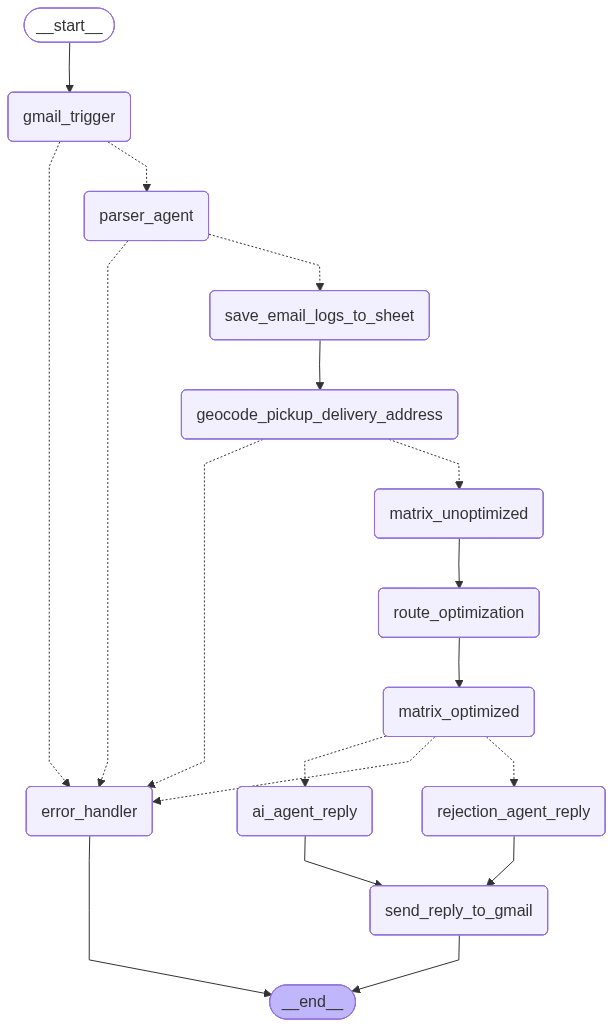

In [19]:
def build_graph():
    builder = StateGraph(LogisticsState)

    # ── Register nodes ───────────────────────────────────────────────
    builder.add_node('gmail_trigger',                   gmail_trigger)
    builder.add_node('parser_agent',                    parser_agent)
    builder.add_node('save_email_logs_to_sheet',        save_email_logs_to_sheet)
    builder.add_node('geocode_pickup_delivery_address', geocode_pickup_delivery_address)
    builder.add_node('matrix_unoptimized',              matrix_unoptimized)
    builder.add_node('route_optimization',              route_optimization)
    builder.add_node('matrix_optimized',                matrix_optimized)
    builder.add_node('ai_agent_reply',                  ai_agent_reply)
    builder.add_node('rejection_agent_reply',           rejection_agent_reply)
    builder.add_node('send_reply_to_gmail',             send_reply_to_gmail)
    builder.add_node('error_handler',                   error_handler)

    # ── Edges: strictly sequential, single path ──────────────────────
    # This guarantees exactly ONE reply email per request.
    #
    # Flow: START → gmail_trigger → parser_agent → save_logs → geocode
    #       → matrix_unoptimized → route_optimization → matrix_optimized
    #       → (ai_reply | rejection_reply) → send_reply → END

    builder.add_edge(START, 'gmail_trigger')

    builder.add_conditional_edges('gmail_trigger', route_after_trigger,
        {'parser_agent': 'parser_agent', 'error_handler': 'error_handler'})

    builder.add_conditional_edges('parser_agent', route_after_parse,
        {'save_email_logs_to_sheet': 'save_email_logs_to_sheet',
         'error_handler': 'error_handler'})

    builder.add_edge('save_email_logs_to_sheet', 'geocode_pickup_delivery_address')

    builder.add_conditional_edges('geocode_pickup_delivery_address', route_after_geocode,
        {'matrix_unoptimized': 'matrix_unoptimized',
         'error_handler': 'error_handler'})

    builder.add_edge('matrix_unoptimized', 'route_optimization')
    builder.add_edge('route_optimization', 'matrix_optimized')

    builder.add_conditional_edges('matrix_optimized', route_after_optimized_matrix,
        {'ai_agent_reply':        'ai_agent_reply',
         'rejection_agent_reply': 'rejection_agent_reply',
         'error_handler':         'error_handler'})

    builder.add_edge('ai_agent_reply',        'send_reply_to_gmail')
    builder.add_edge('rejection_agent_reply', 'send_reply_to_gmail')
    builder.add_edge('send_reply_to_gmail',   END)
    builder.add_edge('error_handler',         END)

    app = builder.compile(checkpointer=MemorySaver())
    log.info(
        'LangGraph compiled: 11 nodes | '
        'Sequential: geocode → matrix_unopt → optimize → matrix_opt → reply → send'
    )
    return app


app = build_graph()
app


## Main Polling Loop

In [20]:
from tools.gmail_tools import poll_gmail_inbox

POLL_INTERVAL = int(os.getenv('GMAIL_POLL_INTERVAL', '60'))
GMAIL_QUERY   = os.getenv('GMAIL_QUERY', 'is:unread subject:Pickup Schedule -from:me')


def process_email(app, raw_email: str, thread_id: str, sender_email: str) -> dict:
    config = {'configurable': {'thread_id': thread_id}}
    state: LogisticsState = {
        'raw_email_content':     raw_email,
        'sender_email':          sender_email,
        'thread_id':             thread_id,
        'collection_request_id': '',
        'parsed_stops':          [],
        'geocoded_stops':        [],
        'sender_company':        '',
        'reply_html':            '',
        'email_log_saved':       False,
        'error':                 None,
        'rejected_stops':        [],
        'depot_latitude':        None,
        'depot_longitude':       None,
        'vehicle_count':         0,
        'opt_summary':           None,
        'opt_routes':            [],
        'ordered_stops':         [],
        'unoptimized_matrix':    None,
        'optimized_matrix':      None,
    }
    log.info('Processing email from %s (thread: %s)', sender_email, thread_id)
    result = app.invoke(state, config=config)

    if result.get('error'):
        log.error('Workflow failed [%s] for thread %s', result['error'], thread_id)
    else:
        log.info('Done. Reply sent to %s (%s)', sender_email, result.get('collection_request_id', ''))
    return result


def main():
    log.info('Gmail polling every %ds. Query: %r', POLL_INTERVAL, GMAIL_QUERY)
    processed_ids: set = set()

    while True:
        try:
            emails = poll_gmail_inbox.invoke({'query': GMAIL_QUERY})
            new_emails = [e for e in emails if e['thread_id'] not in processed_ids]
            if new_emails:
                log.info('Found %d new email(s).', len(new_emails))
            for email in new_emails:
                processed_ids.add(email['thread_id'])
                process_email(app, email['body'], email['thread_id'], email['sender_email'])
        except Exception as exc:
            log.exception('Polling error: %s', exc)
        time.sleep(POLL_INTERVAL)


main()

2026-04-24 23:17:04,775 [INFO] Gmail polling every 60s. Query: 'is:unread subject:Pickup Schedule'
2026-04-24 23:17:06,081 [INFO] Found 1 new email(s).
2026-04-24 23:17:06,083 [INFO] Processing email from Anuj Mumbaikar <anuj.mumbaikar05@gmail.com> (thread: 19dc09907100bfd4)
2026-04-24 23:17:07,902 [INFO] New request: REQ-20260424-17a8ec (thread: 19dc09907100bfd4)
2026-04-24 23:17:12,026 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-24 23:17:12,048 [INFO] Parsed 4 stops (sender: RetailCo India Pvt. Ltd.)
2026-04-24 23:17:17,045 [INFO] Logs saved: 4 stops for REQ-20260424-17a8ec
2026-04-24 23:17:17,973 [INFO] Geocoded 'Growel's 101 Mall, Akurli Road, Borivali East, Mumbai, Maharashtra 400066' → (19.07283, 72.88261) confidence=0.60
2026-04-24 23:17:18,781 [INFO] Geocoded pickup stop 1: (19.07283, 72.88261) conf=0.60
2026-04-24 23:17:19,724 [INFO] Geocoded 'RetailCo Warehouse, Anjur Phata, Bhiwandi, Thane, Maharashtra 421302' → (19.30023, 7

KeyboardInterrupt: 